In [12]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 0. 데이터 로드
#    CSV가 UTF-8인데 중간에 깨진 바이트가 하나 섞여 있어서 encoding_errors='replace' 필요
# ------------------------------------------------------------------
CSV_PATH = "[로데이터] 2025 언론인 조사 원본 데이터.csv"  # 본인 경로로 수정
df = pd.read_csv(CSV_PATH, encoding="utf-8", encoding_errors="replace")
n = len(df)
print(f"전체 응답자 수: {n}")

전체 응답자 수: 2020


In [13]:
# ------------------------------------------------------------------
# 1. 문16 항목 정의 (1~5점, 높을수록 '정당하다'고 인식)
# ------------------------------------------------------------------
Q16_COLS = ["q16_1", "q16_2", "q16_3", "q16_4", "q16_5",
            "q16_6", "q16_7", "q16_8", "q16_9"]
Q16_LABELS = {
    "q16_1": "사적문서 무단사용",
    "q16_2": "비밀문서 무단사용",
    "q16_3": "정보대가 금품제공",
    "q16_4": "위장취재",
    "q16_5": "불편해도 계속 캐묻기",
    "q16_6": "힘든 피해자/유가족 계속취재",
    "q16_7": "신분위장",
    "q16_8": "오프더레코드 위반",
    "q16_9": "엠바고 위반",
}
for c in Q16_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

sub = df[Q16_COLS].dropna()
idx = sub.index  # 원본 df에 클러스터 라벨 붙일 때 이 인덱스 씀
print(f"문16 전체 응답(결측없음) n={len(sub)}")

문16 전체 응답(결측없음) n=2020


In [14]:
# ------------------------------------------------------------------
# 2. 항목간 상관 확인 (구조 파악용) - '신뢰위반' vs '대상침해' 두 축이 있는지 체크
# ------------------------------------------------------------------
print("\n=== 문16 항목 상관행렬 ===")
print(sub.corr().round(2))


=== 문16 항목 상관행렬 ===
       q16_1  q16_2  q16_3  q16_4  q16_5  q16_6  q16_7  q16_8  q16_9
q16_1   1.00   0.61   0.38   0.38   0.35   0.31   0.31   0.26   0.23
q16_2   0.61   1.00   0.39   0.50   0.47   0.27   0.33   0.28   0.24
q16_3   0.38   0.39   1.00   0.43   0.31   0.33   0.34   0.30   0.26
q16_4   0.38   0.50   0.43   1.00   0.50   0.24   0.53   0.28   0.21
q16_5   0.35   0.47   0.31   0.50   1.00   0.51   0.42   0.32   0.26
q16_6   0.31   0.27   0.33   0.24   0.51   1.00   0.33   0.36   0.30
q16_7   0.31   0.33   0.34   0.53   0.42   0.33   1.00   0.40   0.29
q16_8   0.26   0.28   0.30   0.28   0.32   0.36   0.40   1.00   0.73
q16_9   0.23   0.24   0.26   0.21   0.26   0.30   0.29   0.73   1.00


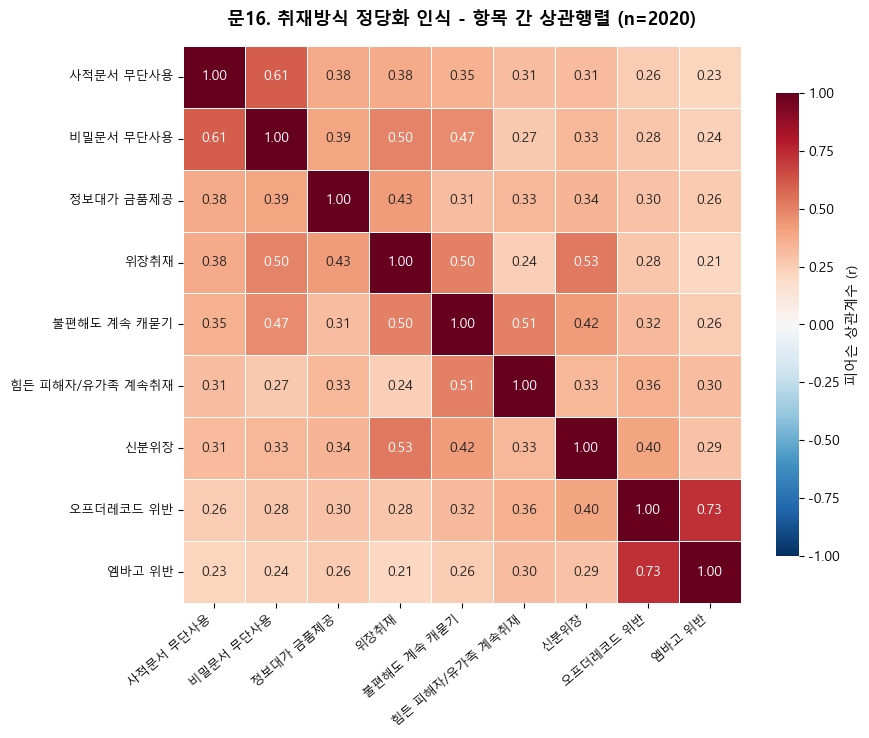

In [15]:
# ------------------------------------------------------------------
# 2-1. 상관행렬 히트맵 시각화
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기준. Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

corr = sub.corr()
corr.index = [Q16_LABELS[c] for c in Q16_COLS]
corr.columns = [Q16_LABELS[c] for c in Q16_COLS]

fig, ax = plt.subplots(figsize=(9, 7.5))

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.6,
    cbar_kws={"label": "피어슨 상관계수 (r)", "shrink": 0.8},
    annot_kws={"size": 10}, ax=ax
)

ax.set_title("문16. 취재방식 정당화 인식 - 항목 간 상관행렬 (n={})".format(len(sub)),
              fontsize=13, pad=15, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("q16_correlation_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

In [16]:
# ------------------------------------------------------------------
# 3. 표준화 -> PCA (구조 확인) -> K-means (k=2~5, 실루엣 확인)
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(sub.values)

pca = PCA(n_components=3)
pcs = pca.fit_transform(X)
print("\n=== PCA 설명분산비율 ===", pca.explained_variance_ratio_)
loadings = pd.DataFrame(pca.components_.T, index=[Q16_LABELS[c] for c in Q16_COLS],
                         columns=["PC1", "PC2", "PC3"])
print(loadings.round(2))

print("\n=== K별 실루엣 스코어 ===")
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(pcs)
    print(f"k={k}: silhouette={silhouette_score(pcs, km.labels_):.3f}")


=== PCA 설명분산비율 === [0.43244112 0.14286225 0.09514818]
                  PC1   PC2   PC3
사적문서 무단사용        0.33 -0.28 -0.47
비밀문서 무단사용        0.36 -0.32 -0.37
정보대가 금품제공        0.32 -0.12 -0.15
위장취재             0.36 -0.28  0.11
불편해도 계속 캐묻기      0.36 -0.14  0.43
힘든 피해자/유가족 계속취재  0.31  0.11  0.49
신분위장             0.34 -0.01  0.31
오프더레코드 위반        0.33  0.56 -0.14
엠바고 위반           0.29  0.61 -0.25

=== K별 실루엣 스코어 ===
k=2: silhouette=0.355
k=3: silhouette=0.305
k=4: silhouette=0.280
k=5: silhouette=0.286


In [17]:
# ------------------------------------------------------------------
# 3-1. k 선택 근거 보강 - 클러스터 구분이 PC1/PC2/PC3 분산을 얼마나 설명하는가
#      (실루엣만으로는 k=2가 더 높게 나오므로, k=3 선택의 이론적 근거를
#       eta-squared로 정량화해서 뒷받침)
# ------------------------------------------------------------------
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3"], index=sub.index)


def eta_squared_by_cluster(pcs_df, cluster_col):
    """클러스터 구분이 각 PC 분산을 설명하는 비율(eta^2) 계산"""
    result = {}
    for pc in ["PC1", "PC2", "PC3"]:
        grand_mean = pcs_df[pc].mean()
        ss_between = sum(
            len(g) * (g[pc].mean() - grand_mean) ** 2
            for _, g in pcs_df.groupby(cluster_col)
        )
        ss_total = sum((pcs_df[pc] - grand_mean) ** 2)
        result[pc] = ss_between / ss_total
    return result


# k=3, k=2 모델을 이 블록 안에서 명시적으로 새로 fit
km3 = KMeans(n_clusters=3, random_state=42, n_init=20).fit(pcs)
km2 = KMeans(n_clusters=2, random_state=42, n_init=20).fit(pcs)

pcs_df["cluster3"] = km3.labels_
pcs_df["cluster2"] = km2.labels_

eta3 = eta_squared_by_cluster(pcs_df, "cluster3")
eta2 = eta_squared_by_cluster(pcs_df, "cluster2")

print("\n=== k별 클러스터 구분이 설명하는 PC 분산 비율 (eta-squared) ===")
eta_table = pd.DataFrame({"k=2": eta2, "k=3": eta3}).T
print((eta_table * 100).round(1).astype(str) + "%")

print("\n=== k=3 클러스터별 PC 평균 ===")
print(pcs_df.groupby("cluster3")[["PC1", "PC2", "PC3"]].mean().round(3))


=== k별 클러스터 구분이 설명하는 PC 분산 비율 (eta-squared) ===
       PC1    PC2   PC3
k=2  65.5%   0.1%  0.1%
k=3  71.5%  40.8%  0.9%

=== k=3 클러스터별 PC 평균 ===
            PC1    PC2    PC3
cluster3                     
0        -1.864  0.236 -0.017
1         0.663 -0.848  0.095
2         2.361  1.035 -0.133


In [18]:
# k=3으로 최종 (k=2는 '전반적 관대함' 단일축만 반영, k=3이 이중잣대 구조를 드러냄)
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=20).fit(pcs)
df.loc[idx, "cluster16"] = km.labels_

In [19]:
# ------------------------------------------------------------------
# 4. 클러스터 프로파일 (문16 항목 평균 + 두 하위축 비교)
# ------------------------------------------------------------------
prof = df.groupby("cluster16")[Q16_COLS].mean()
prof.columns = [Q16_LABELS[c] for c in Q16_COLS]
print("\n=== 클러스터별 문16 항목 평균 ===")
print(prof.T.round(2))

TRUST_VIOL = ["q16_8", "q16_9"]                     # 동료/취재원과의 약속(엠바고, 오프더레코드)
TARGET_INTRUSION = ["q16_1", "q16_2", "q16_4"]  # 대상(취재원/제3자) 침해
trust_score = df.groupby("cluster16")[TRUST_VIOL].mean().mean(axis=1)
target_score = df.groupby("cluster16")[TARGET_INTRUSION].mean().mean(axis=1)

print("\n=== 신뢰위반 점수 vs 대상침해 점수 ===")
print(pd.DataFrame({"신뢰위반": trust_score, "대상침해": target_score}).round(2))

# 클러스터 이름 붙이기 (숫자는 실행마다 바뀔 수 있으니 평균값 기준으로 자동 매핑)
order = target_score.sort_values().index  # 대상침해 점수 기준 정렬
# 대략적 라벨링 로직 (실행 후 수치 보고 직접 확정하는 걸 권장)
name_guess = {}
for cl in df["cluster16"].dropna().unique():
    tv, ti = trust_score[cl], target_score[cl]
    if tv > 2.2 and ti > 2.5:
        name_guess[cl] = "전면 관대형"
    elif tv < 2.0 and ti > 2.5:
        name_guess[cl] = "선택적 정당화형(이중잣대)"
    else:
        name_guess[cl] = "엄격형(전면 준수)"
df["cluster_name"] = df["cluster16"].map(name_guess)
print("\n=== 클러스터명 매핑 결과 ===")
print(df["cluster_name"].value_counts())


=== 클러스터별 문16 항목 평균 ===
cluster16         0.0   1.0   2.0
사적문서 무단사용        1.81  2.90  3.14
비밀문서 무단사용        1.97  3.56  3.60
정보대가 금품제공        1.27  2.14  2.50
위장취재             2.11  3.55  3.55
불편해도 계속 캐묻기      2.17  3.46  3.75
힘든 피해자/유가족 계속취재  1.40  2.01  2.66
신분위장             1.77  2.77  3.24
오프더레코드 위반        1.35  1.56  3.04
엠바고 위반           1.40  1.45  2.90

=== 신뢰위반 점수 vs 대상침해 점수 ===
           신뢰위반  대상침해
cluster16            
0.0        1.38  1.97
1.0        1.50  3.33
2.0        2.97  3.43

=== 클러스터명 매핑 결과 ===
엄격형(전면 준수)        823
선택적 정당화형(이중잣대)    761
전면 관대형            436
Name: cluster_name, dtype: int64


In [20]:
# ------------------------------------------------------------------
# 4-1. 하위척도 내적 일관성 검증 (Cronbach's alpha)
#      신뢰위반(q16_8,9)과 대상침해(q16_1,2,4)가 각각 하나의 척도로
#      묶일 만한 내적 일관성을 갖는지 확인
# ------------------------------------------------------------------
def cronbach_alpha(items_df):
    k = items_df.shape[1]
    item_vars = items_df.var(axis=0, ddof=1)
    total_var = items_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alpha_trust = cronbach_alpha(sub[TRUST_VIOL])
alpha_target = cronbach_alpha(sub[TARGET_INTRUSION])

print("\n=== 하위척도 내적 일관성 (Cronbach's alpha) ===")
print(f"신뢰위반  ({', '.join(TRUST_VIOL)}, {len(TRUST_VIOL)}문항): alpha = {alpha_trust:.3f}")
print(f"대상침해  ({', '.join(TARGET_INTRUSION)}, {len(TARGET_INTRUSION)}문항): alpha = {alpha_target:.3f}")


=== 하위척도 내적 일관성 (Cronbach's alpha) ===
신뢰위반  (q16_8, q16_9, 2문항): alpha = 0.841
대상침해  (q16_1, q16_2, q16_4, 3문항): alpha = 0.746


In [21]:
# ------------------------------------------------------------------
# 5. 인구통계/직급/경험 변수와 교차 (누가 이중잣대형인가?)
# ------------------------------------------------------------------
for c in ["SQ1", "SQ7", "DQ1", "DQ2", "DQ5", "q27", "q11", "q1_6", "q14", "q29", "q9_4"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["age"] = df["DQ2"]
df["career_years"] = 2025 - df["DQ5"]

print("\n=== 클러스터별 연령/경력 ===")
print(df.groupby("cluster_name")[["age", "career_years"]].mean().round(1))

print("\n=== 클러스터별 직위분포(SQ7, %) ===")
print((pd.crosstab(df["cluster_name"], df["SQ7"], normalize="index") * 100).round(1))

print("\n=== 클러스터별 성별분포(DQ1, %) ===")
print((pd.crosstab(df["cluster_name"], df["DQ1"], normalize="index") * 100).round(1))

print("\n=== 클러스터별 이념성향(q27, 0=진보~10=보수) ===")
print(df.groupby("cluster_name")["q27"].mean().round(2))

print("\n=== 클러스터별 괴롭힘 경험률(q29==1, %) ===")
df["harassed"] = (df["q29"] == 1).astype(float)
print((df.groupby("cluster_name")["harassed"].mean() * 100).round(1))

print("\n=== 클러스터별 인격권침해원인=특종경쟁(q14==2, %) ===")
df["blame_comp"] = (df["q14"] == 2).astype(float)
print((df.groupby("cluster_name")["blame_comp"].mean() * 100).round(1))

print("\n=== 클러스터별 평균 디지털 혁신 피로도(q5, 1~5점) ===")
print(df.groupby("cluster_name")["q5"].mean().round(2))




=== 클러스터별 연령/경력 ===
                 age  career_years
cluster_name                      
선택적 정당화형(이중잣대)  39.6          12.1
엄격형(전면 준수)      44.2          15.0
전면 관대형          40.2          12.7

=== 클러스터별 직위분포(SQ7, %) ===
SQ7                1    2     3     4     5
cluster_name                               
선택적 정당화형(이중잣대)   7.6  3.3  12.7  18.3  58.1
엄격형(전면 준수)      15.1  7.4  19.1  18.0  40.5
전면 관대형           5.7  5.0  15.8  20.0  53.4

=== 클러스터별 성별분포(DQ1, %) ===
DQ1                1     2
cluster_name              
선택적 정당화형(이중잣대)  63.9  36.1
엄격형(전면 준수)      68.3  31.7
전면 관대형          68.6  31.4

=== 클러스터별 이념성향(q27, 0=진보~10=보수) ===
cluster_name
선택적 정당화형(이중잣대)    4.47
엄격형(전면 준수)        4.85
전면 관대형            4.55
Name: q27, dtype: float64

=== 클러스터별 괴롭힘 경험률(q29==1, %) ===
cluster_name
선택적 정당화형(이중잣대)    40.1
엄격형(전면 준수)        29.5
전면 관대형            39.4
Name: harassed, dtype: float64

=== 클러스터별 인격권침해원인=특종경쟁(q14==2, %) ===
cluster_name
선택적 정당화형(이중잣대)    37.7
엄격형(전면 준수)        32.7
전면 

In [22]:
# ------------------------------------------------------------------
# 5-1. 인격권침해원인=특종경쟁(q14==2) 카이제곱 검정
#      클러스터별 지목률 차이가 통계적으로 유의한지 확인
# ------------------------------------------------------------------
from scipy.stats import chi2_contingency

ctab = pd.crosstab(df["cluster_name"], df["blame_comp"])
chi2, p, dof, expected = chi2_contingency(ctab)

print("\n=== 교차표 (인격권침해원인=특종경쟁 지목 여부) ===")
print(ctab)
print(f"\nchi2 = {chi2:.3f}, p-value = {p:.5f}, dof = {dof}")

# 참고: 효과크기 Cramer's V
n = ctab.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ctab.shape) - 1)))
print(f"Cramer's V = {cramers_v:.3f}")


=== 교차표 (인격권침해원인=특종경쟁 지목 여부) ===
blame_comp      0.0  1.0
cluster_name            
선택적 정당화형(이중잣대)  474  287
엄격형(전면 준수)      554  269
전면 관대형          254  182

chi2 = 10.817, p-value = 0.00448, dof = 2
Cramer's V = 0.073
